# 04_02 — Model Evaluation & Comparison (Extended Sweep)

Automatically scans all trained models in `experiment_model/models_02/`, extracts
evaluation metrics, and generates group-based comparison reports and visualizations.

**Model folder naming convention:**  
`{learningrate}_{batchsize}_{inputtype}_{modeltype}_{dropout}_{l2_reg}_{label_smoothing}_{lstmunits}`  
**Example:** `-3_16_processed_lstm_0.1_0.0001_0.05_128-64`

---

## Notebook Sections
1. Import Libraries  
2. Configuration & Paths  
3. Load & Parse Model Metadata  
4. Data Overview  
5. Group-Based Analysis & Visualization  
   - 5.1 By Learning Rate  
   - 5.2 By Batch Size  
   - 5.3 By Input Type  
   - 5.4 By Model Type  
   - 5.5 By Dropout Rate  
   - 5.6 By L2 Regularization  
   - 5.7 By LSTM Units (Architecture)  
6. Category Rankings  
7. Global Top-5 Rankings  
8. Summary & Conclusions  
9. Best Model Deep-Dive  

## 1. Import Libraries

In [18]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Configuration & Paths

All path and constant definitions live here — edit this cell to adapt to a
different directory layout.

In [19]:
NOTEBOOK_DIR = Path().resolve()
BASE_DIR     = NOTEBOOK_DIR.parent
MODELS_DIR   = BASE_DIR / 'models_02'
LOGS_DIR     = BASE_DIR / 'logs' / 'training'

METRICS = ['acc', 'val_acc', 'recall', 'f1_score']

METRIC_LABELS = {
    'acc':      'Accuracy (Test)',
    'val_acc':  'Validation Accuracy',
    'recall':   'Recall',
    'f1_score': 'F1 Score',
}

CATEGORY_LABELS = {
    'learningrate': 'Learning Rate',
    'batchsize':    'Batch Size',
    'inputtype':    'Input Type',
    'modeltype':    'Model Type',
    'dropout':      'Dropout Rate',
    'l2_reg':       'L2 Regularization',
    'lstmunits':    'LSTM Units (Architecture)',
}

print(f'Base directory  : {BASE_DIR}')
print(f'Models directory: {MODELS_DIR}')
print(f'Logs directory  : {LOGS_DIR}')

if MODELS_DIR.exists():
    n_dirs = sum(1 for p in MODELS_DIR.iterdir() if p.is_dir())
    print(f'Model folders found: {n_dirs}')
else:
    print('WARNING: Models directory not found!')

Base directory  : C:\Users\Napat\termtemsl\experiment_model
Models directory: C:\Users\Napat\termtemsl\experiment_model\models_02
Logs directory  : C:\Users\Napat\termtemsl\experiment_model\logs\training
Model folders found: 127


## 3. Load & Parse Model Metadata

**Folder naming convention:**  
`{lr_exp}_{batch}_{inputtype}_{modeltype}_{dropout}_{l2_reg}_{label_smoothing}_{units}`

**Metric sources (in priority order):**
- `acc`, `recall`, `f1_score` ← `metrics.json` (validation-set evaluation)
- `val_acc` ← `analysis_summary.json` (`underfitting.best_val_acc`)
- `val_acc` fallback ← `logs/training/{exp}.json` (Keras training history)

Missing files are handled gracefully; models with no loadable metrics are skipped.

In [20]:
_MODEL_TYPES = {'lstm', 'gru'}


def parse_folder_name(name: str) -> dict | None:
    '''Parse experiment folder name into its seven components.

    Convention : {lr_exp}_{batch}_{inputtype}_{modeltype}_{dropout}_{l2_reg}_{label_smoothing}_{units}
    Example    : -3_16_processed_lstm_0.1_0.0001_0.05_128-64
    Returns None if the name does not match the expected structure.
    '''
    parts = name.split('_')
    if len(parts) < 8:
        return None

    lr_exp    = parts[0]
    batchsize = parts[1]

    mt_idx = None
    for i in range(2, len(parts)):
        if parts[i] in _MODEL_TYPES:
            mt_idx = i
            break
    if mt_idx is None:
        return None

    inputtype = '_'.join(parts[2:mt_idx])
    modeltype = parts[mt_idx]

    tail = parts[mt_idx + 1:]
    if len(tail) < 4:
        return None

    dropout_str, l2_str, _ls_str, units_str = tail[0], tail[1], tail[2], tail[3]

    try:
        batchsize = int(batchsize)
        dropout   = float(dropout_str)
        l2_reg    = float(l2_str)
    except ValueError:
        return None

    return {
        'learningrate': lr_exp,
        'batchsize':    batchsize,
        'inputtype':    inputtype,
        'modeltype':    modeltype,
        'dropout':      dropout,
        'l2_reg':       l2_reg,
        'lstmunits':    units_str,
    }


def load_model_data(model_dir: Path) -> dict:
    '''Load evaluation metrics for a single model directory.

    Returns a (possibly partial) dict with keys: acc, val_acc, recall, f1_score.
    Missing values are left as NaN via pd.to_numeric downstream.
    '''
    data = {}

    metrics_path = model_dir / 'metrics.json'
    if metrics_path.exists():
        try:
            with open(metrics_path) as f:
                m = json.load(f)
            data['acc']      = m.get('accuracy')
            data['recall']   = m.get('macro_recall')
            data['f1_score'] = m.get('macro_f1')
        except Exception:
            pass

    summary_path = model_dir / 'analysis_summary.json'
    if summary_path.exists():
        try:
            with open(summary_path) as f:
                s = json.load(f)
            for section in ('underfitting', 'overfitting'):
                val = s.get(section, {}).get('best_val_acc')
                if val is not None:
                    data['val_acc'] = val
                    break
        except Exception:
            pass

    if data.get('val_acc') is None:
        log_path = LOGS_DIR / f'{model_dir.name}.json'
        if log_path.exists():
            try:
                with open(log_path) as f:
                    log = json.load(f)
                for key in ('val_accuracy', 'val_acc'):
                    hist_vals = log.get('history', {}).get(key) or log.get(key)
                    if hist_vals:
                        if isinstance(hist_vals, list):
                            data['val_acc'] = max(hist_vals)
                        else:
                            data['val_acc'] = hist_vals
                        break
                if data.get('val_acc') is None:
                    for key in ('best_val_accuracy', 'best_val_acc'):
                        v = log.get(key)
                        if v is not None:
                            data['val_acc'] = v
                            break
            except Exception:
                pass

    return data


records = []
skipped = []

if not MODELS_DIR.exists():
    print(f'ERROR: Models directory not found at {MODELS_DIR}')
else:
    for model_dir in sorted(MODELS_DIR.iterdir()):
        if not model_dir.is_dir():
            continue

        parsed = parse_folder_name(model_dir.name)
        if parsed is None:
            skipped.append(model_dir.name)
            continue

        metrics = load_model_data(model_dir)
        if not metrics:
            skipped.append(model_dir.name)
            continue

        records.append({'model': model_dir.name, **parsed, **metrics})

df = pd.DataFrame(records)

for col in METRICS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Models loaded : {len(df)}')
if skipped:
    preview = skipped[:5]
    more    = f'... (+{len(skipped) - 5} more)' if len(skipped) > 5 else ''
    print(f'Skipped ({len(skipped)}): {preview} {more}')

Models loaded : 126
Skipped (1): ['-4_16_oldprocessed_gru_0.2_0.0001_0.05_128-64'] 


## 4. Data Overview

Quick sanity check on the loaded data before analysis.

In [21]:
print(f'DataFrame shape : {df.shape}')
print(f'\nUnique values per grouping category:')
for col, label in CATEGORY_LABELS.items():
    if col in df.columns:
        vals = sorted(df[col].unique().tolist(), key=lambda x: (str(type(x)), x))
        print(f'  {label:30s}: {vals}')

print(f'\nMetric coverage (non-null counts out of {len(df)}):')
for col in METRICS:
    if col in df.columns:
        n = df[col].notna().sum()
        pct = 100 * n / len(df)
        print(f'  {METRIC_LABELS[col]:25s}: {n}/{len(df)} ({pct:.0f}%)')

print(f'\nDescriptive statistics:')
display(df[METRICS].describe().round(4))

DataFrame shape : (126, 12)

Unique values per grouping category:
  Learning Rate                 : ['-3', '-4']
  Batch Size                    : [8, 16]
  Input Type                    : ['oldprocessed', 'processed']
  Model Type                    : ['gru', 'lstm']
  Dropout Rate                  : [0.1, 0.2]
  L2 Regularization             : [0.0001, 0.001]
  LSTM Units (Architecture)     : ['128-64', '128-64-32']

Metric coverage (non-null counts out of 126):
  Accuracy (Test)          : 126/126 (100%)
  Validation Accuracy      : 126/126 (100%)
  Recall                   : 126/126 (100%)
  F1 Score                 : 126/126 (100%)

Descriptive statistics:


,acc,val_acc,recall,f1_score
count,126.0000,126.0000,126.0000,126.0000
mean,0.1456,0.2067,0.1456,0.0926
std,0.1006,0.1017,0.1006,0.0978
min,0.0414,0.0828,0.0414,0.0165
25%,0.0897,0.1250,0.0897,0.0366
50%,0.1086,0.1640,0.1086,0.0572
75%,0.1431,0.2690,0.1431,0.0776
max,0.4813,0.4812,0.4813,0.4278


In [22]:
display(
    df[['model', 'learningrate', 'batchsize', 'inputtype', 'modeltype',
        'dropout', 'l2_reg', 'lstmunits'] + METRICS]
    .head(10)
    .style.format({m: '{:.4f}' for m in METRICS}, na_rep='N/A')
    .set_caption('Sample of loaded model data')
)

,model,learningrate,batchsize,inputtype,modeltype,dropout,l2_reg,lstmunits,acc,val_acc,recall,f1_score
0,-3_16_oldprocessed_gru_0.1_0.0001_0.05_128-64,-3,16,oldprocessed,gru,0.100000,0.000100,128-64,0.1000,0.2552,0.1000,0.0242
1,-3_16_oldprocessed_gru_0.1_0.0001_0.05_128-64-32,-3,16,oldprocessed,gru,0.100000,0.000100,128-64-32,0.1172,0.2345,0.1172,0.0512
2,-3_16_oldprocessed_gru_0.1_0.001_0.05_128-64,-3,16,oldprocessed,gru,0.100000,0.001000,128-64,0.1759,0.2483,0.1759,0.1310
3,-3_16_oldprocessed_gru_0.1_0.001_0.05_128-64-32,-3,16,oldprocessed,gru,0.100000,0.001000,128-64-32,0.2621,0.2828,0.2621,0.1572
4,-3_16_oldprocessed_gru_0.2_0.0001_0.05_128-64,-3,16,oldprocessed,gru,0.200000,0.000100,128-64,0.0828,0.2345,0.0828,0.0434
5,-3_16_oldprocessed_gru_0.2_0.0001_0.05_128-64-32,-3,16,oldprocessed,gru,0.200000,0.000100,128-64-32,0.1345,0.2931,0.1345,0.0563
6,-3_16_oldprocessed_gru_0.2_0.001_0.05_128-64,-3,16,oldprocessed,gru,0.200000,0.001000,128-64,0.2207,0.2517,0.2207,0.1990
7,-3_16_oldprocessed_gru_0.2_0.001_0.05_128-64-32,-3,16,oldprocessed,gru,0.200000,0.001000,128-64-32,0.2586,0.3000,0.2586,0.1693
8,-3_16_oldprocessed_lstm_0.1_0.0001_0.05_128-64,-3,16,oldprocessed,lstm,0.100000,0.000100,128-64,0.1069,0.2379,0.1069,0.0650
9,-3_16_oldprocessed_lstm_0.1_0.0001_0.05_128-64-32,-3,16,oldprocessed,lstm,0.100000,0.000100,128-64-32,0.3172,0.3414,0.3172,0.2496


## Helper Functions

Shared utilities for grouping and plotting — used by all analysis sections below.

In [23]:
COLORS  = sns.color_palette('tab10', n_colors=4)
MARKERS = ['o', 's', '^', 'D']


def compute_group_means(data: pd.DataFrame, group_col: str) -> pd.DataFrame:
    '''Return a DataFrame of per-group metric averages.

    Index  = unique values of group_col
    Columns = METRICS (those present in data)
    '''
    available = [m for m in METRICS if m in data.columns]
    return data.groupby(group_col)[available].mean().round(4)


def plot_group_metrics(group_df: pd.DataFrame,
                       x_label:  str,
                       title:    str) -> None:
    '''Line chart comparing all four metrics across groups.

    group_df : result of compute_group_means() — index = group labels
    x_label  : x-axis label (name of the grouping category)
    title    : plot title
    '''
    fig, ax = plt.subplots(figsize=(max(8, len(group_df) * 2), 5))

    x_labels = [str(v) for v in group_df.index.tolist()]
    x_pos    = list(range(len(x_labels)))

    for i, metric in enumerate(METRICS):
        if metric not in group_df.columns:
            continue
        values = group_df[metric].tolist()
        ax.plot(x_pos, values,
                marker=MARKERS[i], color=COLORS[i],
                linewidth=2.2, markersize=9,
                label=METRIC_LABELS[metric])
        for j, v in enumerate(values):
            if pd.notna(v):
                ax.annotate(
                    f'{v:.3f}',
                    xy=(x_pos[j], v),
                    textcoords='offset points',
                    xytext=(0, 9),
                    ha='center',
                    fontsize=8.5,
                    color=COLORS[i],
                    fontweight='semibold',
                )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_xlabel(x_label, fontsize=12, labelpad=8)
    ax.set_ylabel('Average Metric Value', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.legend(loc='best', framealpha=0.9, edgecolor='#cccccc')
    ax.set_ylim(0, 1.18)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()


print('Helper functions defined.')

Helper functions defined.


## 5. Group-Based Analysis & Visualization

For each grouping category the models are partitioned and their metrics are
averaged within each group. A line chart then shows how each average metric
changes across the groups in that category.

### 5.1  Group by Learning Rate

The `learningrate` column stores the base-10 exponent (e.g., `-3` means 10⁻³).
Groups are ordered from highest exponent (fastest LR) to lowest.

Average metrics grouped by Learning Rate (log₁₀ exponent):


,acc,val_acc,recall,f1_score
learningrate,,,,
-4,0.0954,0.1294,0.0954,0.0452
-3,0.1942,0.2817,0.1942,0.1386


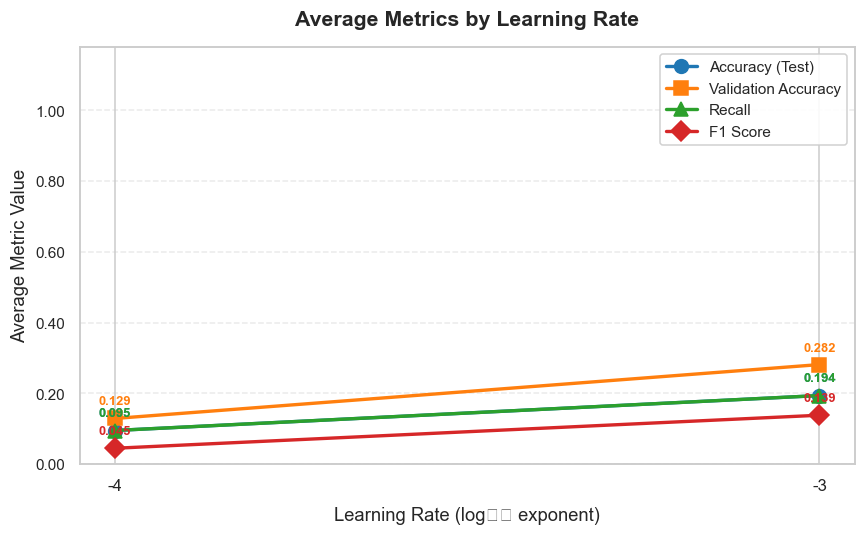

In [24]:
lr_means = compute_group_means(df, 'learningrate')

lr_order = sorted(lr_means.index, key=lambda x: int(x))
lr_means = lr_means.loc[lr_order]

print('Average metrics grouped by Learning Rate (log₁₀ exponent):')
display(
    lr_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    lr_means,
    x_label='Learning Rate (log₁₀ exponent)',
    title='Average Metrics by Learning Rate',
)

### 5.2  Group by Batch Size

Average metrics grouped by Batch Size:


,acc,val_acc,recall,f1_score
batchsize,,,,
8,0.1561,0.2170,0.1561,0.1058
16,0.1347,0.1962,0.1347,0.0790


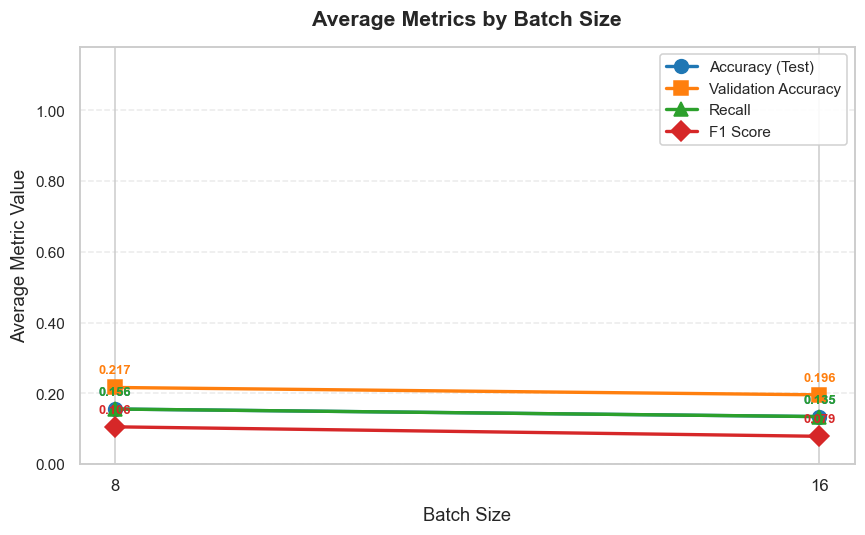

In [25]:
bs_means = compute_group_means(df, 'batchsize').sort_index()

print('Average metrics grouped by Batch Size:')
display(
    bs_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    bs_means,
    x_label='Batch Size',
    title='Average Metrics by Batch Size',
)

### 5.3  Group by Input Type

Average metrics grouped by Input Type:


,acc,val_acc,recall,f1_score
inputtype,,,,
oldprocessed,0.1333,0.1978,0.1333,0.0791
processed,0.1578,0.2157,0.1578,0.1061


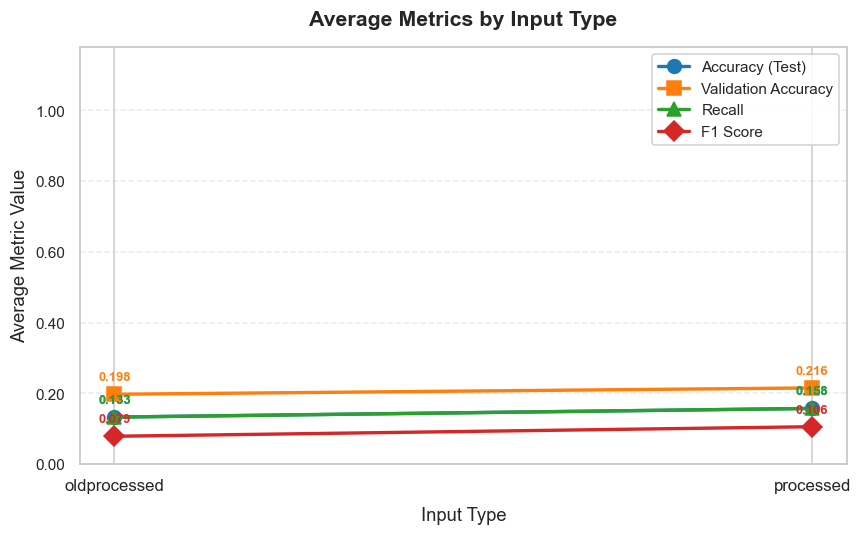

In [26]:
it_means = compute_group_means(df, 'inputtype').sort_index()

print('Average metrics grouped by Input Type:')
display(
    it_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    it_means,
    x_label='Input Type',
    title='Average Metrics by Input Type',
)

### 5.4  Group by Model Type

Average metrics grouped by Model Type:


,acc,val_acc,recall,f1_score
modeltype,,,,
gru,0.1582,0.2298,0.1582,0.1077
lstm,0.1334,0.1844,0.1334,0.0780


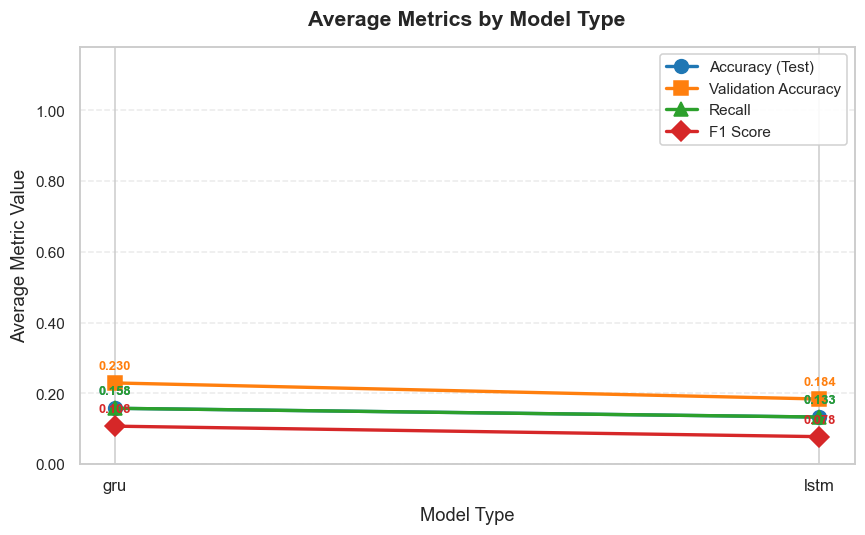

In [27]:
mt_means = compute_group_means(df, 'modeltype').sort_index()

print('Average metrics grouped by Model Type:')
display(
    mt_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    mt_means,
    x_label='Model Type',
    title='Average Metrics by Model Type',
)

### 5.5  Group by Dropout Rate

Average metrics grouped by Dropout Rate:


,acc,val_acc,recall,f1_score
dropout,,,,
0.100000,0.1527,0.2091,0.1527,0.0964
0.200000,0.1382,0.2043,0.1382,0.0887


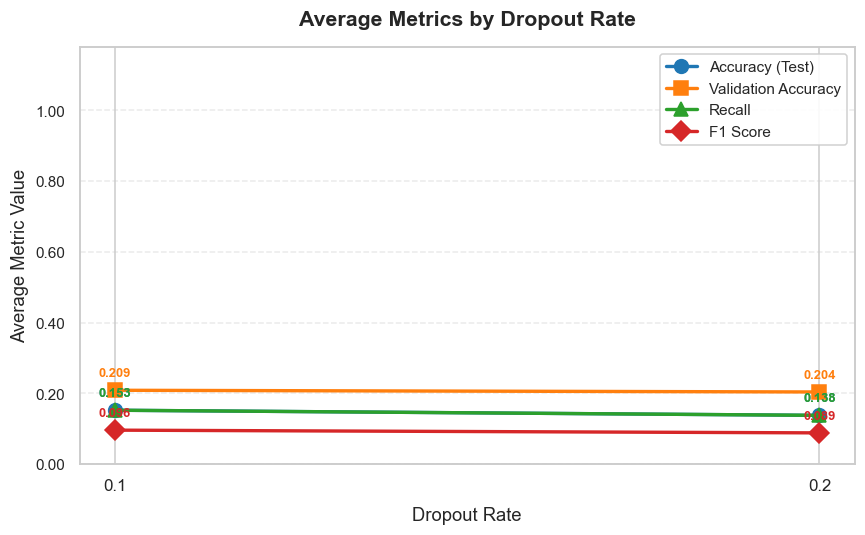

In [28]:
do_means = compute_group_means(df, 'dropout').sort_index()

print('Average metrics grouped by Dropout Rate:')
display(
    do_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    do_means,
    x_label='Dropout Rate',
    title='Average Metrics by Dropout Rate',
)

### 5.6  Group by L2 Regularization

Groups are ordered from strongest regularization (largest L2) to weakest.

Average metrics grouped by L2 Regularization:


,acc,val_acc,recall,f1_score
l2_reg,,,,
0.001000,0.1642,0.2098,0.1642,0.1113
0.000100,0.1263,0.2036,0.1263,0.0734


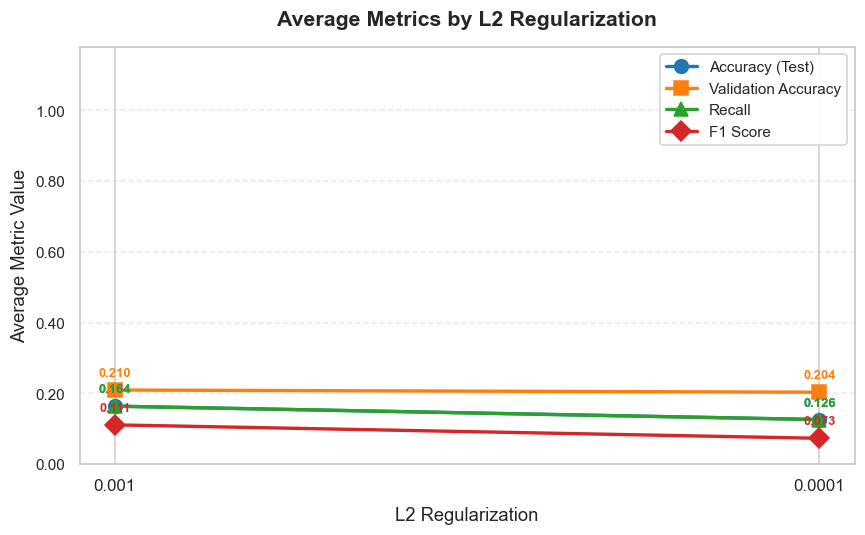

In [29]:
l2_means = compute_group_means(df, 'l2_reg')

l2_order = sorted(l2_means.index, reverse=True)
l2_means = l2_means.loc[l2_order]

print('Average metrics grouped by L2 Regularization:')
display(
    l2_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    l2_means,
    x_label='L2 Regularization',
    title='Average Metrics by L2 Regularization',
)

### 5.7  Group by LSTM Units (Architecture)

`128-64` = two recurrent layers (128 → 64 units)  
`128-64-32` = three recurrent layers (128 → 64 → 32 units)

Average metrics grouped by LSTM Units (Architecture):


,acc,val_acc,recall,f1_score
lstmunits,,,,
128-64-32,0.1504,0.2130,0.1504,0.0952
128-64,0.1406,0.2002,0.1406,0.0899


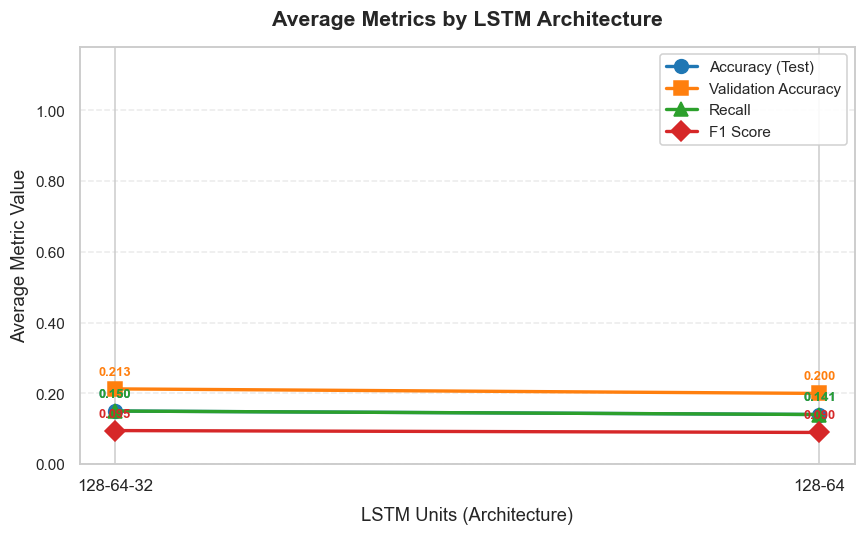

In [30]:
def _unit_sort_key(s):
    parts = [int(x) for x in s.split('-')]
    return (-len(parts), -sum(parts))

units_means = compute_group_means(df, 'lstmunits')
units_order = sorted(units_means.index, key=_unit_sort_key)
units_means = units_means.loc[units_order]

print('Average metrics grouped by LSTM Units (Architecture):')
display(
    units_means.style
    .format('{:.4f}', na_rep='N/A')
    .highlight_max(axis=0, color='#c6efce')
    .set_caption('Green = best value in each column')
)

plot_group_metrics(
    units_means,
    x_label='LSTM Units (Architecture)',
    title='Average Metrics by LSTM Architecture',
)

## 6. Category Rankings

For each grouping category, rank the options from best to worst for every metric.

In [31]:
def print_category_rankings(data: pd.DataFrame,
                             group_col: str,
                             category_label: str) -> None:
    '''Print ranked options for every metric within one grouping category.'''
    group_means = compute_group_means(data, group_col)

    sep = '=' * 62
    print(f'\n{sep}')
    print(f'  Rankings by {category_label}')
    print(sep)

    for metric, metric_label in METRIC_LABELS.items():
        if metric not in group_means.columns:
            continue
        ranked = (
            group_means[metric]
            .dropna()
            .sort_values(ascending=False)
        )
        if ranked.empty:
            continue
        print(f'\n  Best {category_label} by {metric_label}:')
        for rank, (name, val) in enumerate(ranked.items(), start=1):
            bar = '#' * int(val * 20)
            print(f'    {rank}. {str(name):20s}  {val:.4f}  {bar}')


for col, label in CATEGORY_LABELS.items():
    if col in df.columns:
        print_category_rankings(df, col, label)


  Rankings by Learning Rate

  Best Learning Rate by Accuracy (Test):
    1. -3                    0.1942  ###
    2. -4                    0.0954  #

  Best Learning Rate by Validation Accuracy:
    1. -3                    0.2817  #####
    2. -4                    0.1294  ##

  Best Learning Rate by Recall:
    1. -3                    0.1942  ###
    2. -4                    0.0954  #

  Best Learning Rate by F1 Score:
    1. -3                    0.1386  ##
    2. -4                    0.0452  

  Rankings by Batch Size

  Best Batch Size by Accuracy (Test):
    1. 8                     0.1561  ###
    2. 16                    0.1347  ##

  Best Batch Size by Validation Accuracy:
    1. 8                     0.2170  ####
    2. 16                    0.1962  ###

  Best Batch Size by Recall:
    1. 8                     0.1561  ###
    2. 16                    0.1347  ##

  Best Batch Size by F1 Score:
    1. 8                     0.1058  ##
    2. 16                    0.0790  #


## 7. Global Top-5 Rankings

Overall rankings across **all individual models** (no grouping) for each metric.

In [32]:
TOP_N = 5

print('=' * 72)
print('  GLOBAL MODEL RANKINGS  (Individual Models — No Grouping)')
print('=' * 72)

for metric, metric_label in METRIC_LABELS.items():
    if metric not in df.columns:
        continue

    top = (
        df[['model', metric]]
        .dropna(subset=[metric])
        .nlargest(TOP_N, metric)
        .reset_index(drop=True)
    )

    print(f'\n  Top {TOP_N} Models by {metric_label}:')
    if top.empty:
        print('    (no data available)')
        continue
    for i, row in top.iterrows():
        print(f'    {i + 1}. {row["model"]:60s}  ({row[metric]:.4f})')

  GLOBAL MODEL RANKINGS  (Individual Models — No Grouping)

  Top 5 Models by Accuracy (Test):
    1. -3_8_processed_gru_0.2_0.001_0.05_128-64                      (0.4813)
    2. -3_16_processed_gru_0.1_0.001_0.05_128-64                     (0.4688)
    3. -3_8_processed_gru_0.1_0.0001_0.05_128-64                     (0.4562)
    4. -3_8_processed_gru_0.1_0.001_0.05_128-64-32                   (0.4313)
    5. -3_8_processed_gru_0.2_0.001_0.05_128-64-32                   (0.4250)

  Top 5 Models by Validation Accuracy:
    1. -3_8_processed_gru_0.1_0.001_0.05_128-64-32                   (0.4812)
    2. -3_8_processed_gru_0.2_0.001_0.05_128-64                      (0.4812)
    3. -3_16_processed_gru_0.1_0.001_0.05_128-64                     (0.4688)
    4. -3_8_processed_gru_0.1_0.001_0.05_128-64                      (0.4625)
    5. -3_8_processed_gru_0.1_0.0001_0.05_128-64                     (0.4563)

  Top 5 Models by Recall:
    1. -3_8_processed_gru_0.2_0.001_0.05_128-64           

## 8. Summary & Conclusions

Consolidate the best option per category × metric into a single summary table,
then print readable key takeaways.

In [33]:
rows = []
for col, cat_label in CATEGORY_LABELS.items():
    if col not in df.columns:
        continue
    gm = compute_group_means(df, col)
    for metric, metric_label in METRIC_LABELS.items():
        if metric not in gm.columns or gm[metric].isna().all():
            continue
        best_name = gm[metric].idxmax()
        best_val  = gm[metric].max()
        rows.append({
            'Category':    cat_label,
            'Metric':      metric_label,
            'Best Option': str(best_name),
            'Avg Value':   round(best_val, 4),
        })

summary_df = pd.DataFrame(rows)

print('SUMMARY: Best Option per Category × Metric')
print('=' * 72)
display(
    summary_df.style
    .set_caption('Best-performing configuration for each category and metric')
)

print('\n\nKEY TAKEAWAYS')
print('=' * 72)
for metric, metric_label in METRIC_LABELS.items():
    subset = summary_df[summary_df['Metric'] == metric_label]
    if subset.empty:
        continue
    print(f'\n{metric_label}:')
    for _, row in subset.iterrows():
        print(f'  Best {row["Category"]:30s}: {row["Best Option"]}  ({row["Avg Value"]:.4f})')

SUMMARY: Best Option per Category × Metric


,Category,Metric,Best Option,Avg Value
0,Learning Rate,Accuracy (Test),-3,0.194200
1,Learning Rate,Validation Accuracy,-3,0.281700
2,Learning Rate,Recall,-3,0.194200
3,Learning Rate,F1 Score,-3,0.138600
4,Batch Size,Accuracy (Test),8,0.156100
5,Batch Size,Validation Accuracy,8,0.217000
6,Batch Size,Recall,8,0.156100
7,Batch Size,F1 Score,8,0.105800
8,Input Type,Accuracy (Test),processed,0.157800
9,Input Type,Validation Accuracy,processed,0.215700




KEY TAKEAWAYS

Accuracy (Test):
  Best Learning Rate                 : -3  (0.1942)
  Best Batch Size                    : 8  (0.1561)
  Best Input Type                    : processed  (0.1578)
  Best Model Type                    : gru  (0.1582)
  Best Dropout Rate                  : 0.1  (0.1527)
  Best L2 Regularization             : 0.001  (0.1642)
  Best LSTM Units (Architecture)     : 128-64-32  (0.1504)

Validation Accuracy:
  Best Learning Rate                 : -3  (0.2817)
  Best Batch Size                    : 8  (0.2170)
  Best Input Type                    : processed  (0.2157)
  Best Model Type                    : gru  (0.2298)
  Best Dropout Rate                  : 0.1  (0.2091)
  Best L2 Regularization             : 0.001  (0.2098)
  Best LSTM Units (Architecture)     : 128-64-32  (0.2130)

Recall:
  Best Learning Rate                 : -3  (0.1942)
  Best Batch Size                    : 8  (0.1561)
  Best Input Type                    : processed  (0.1578)
  Best Mo

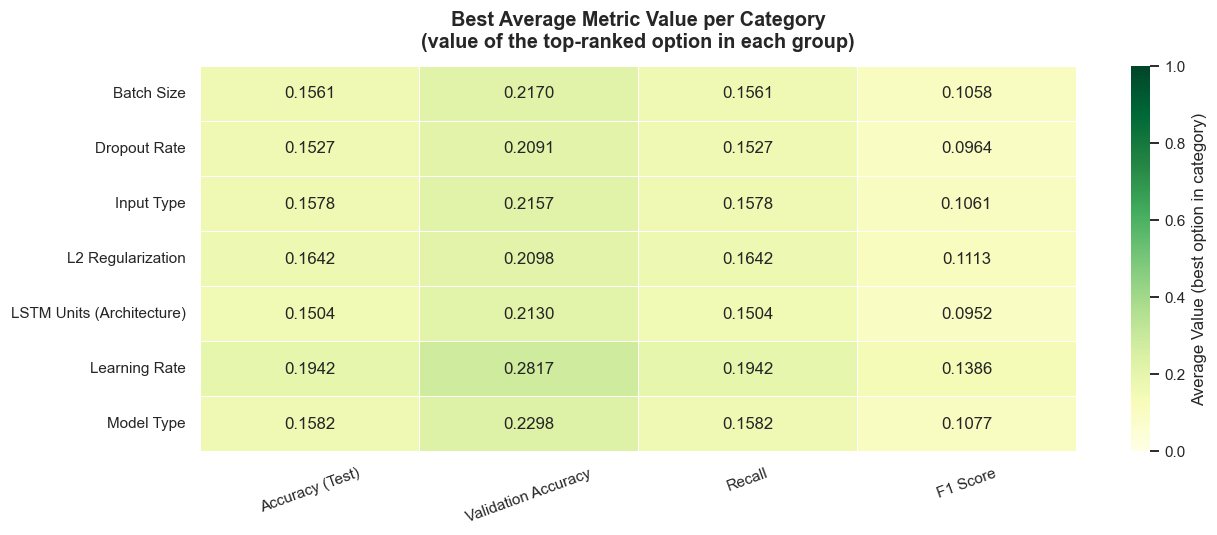

In [34]:
pivot = summary_df.pivot(index='Category', columns='Metric', values='Avg Value')
pivot = pivot[[ml for ml in METRIC_LABELS.values() if ml in pivot.columns]]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot.astype(float),
    annot=True,
    fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Average Value (best option in category)'},
    vmin=0,
    vmax=1,
)
ax.set_title(
    'Best Average Metric Value per Category\n(value of the top-ranked option in each group)',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 9. Best Model Deep-Dive

Detailed inspection of the single best-performing model selected from the sweep.

**Model:** `-3_8_processed_gru_0.2_0.001_0.05_128-64`  
**Config:** GRU · processed input · LR 10⁻³ · batch 8 · dropout 0.2 · L2 0.001 · units 128→64

In [35]:
BEST_MODEL_NAME = '-3_8_processed_gru_0.2_0.001_0.05_128-64'
BEST_MODEL_DIR  = MODELS_DIR / BEST_MODEL_NAME

def _load_json(path: Path) -> dict:
    with open(path) as f:
        return json.load(f)

bm_config     = _load_json(BEST_MODEL_DIR / 'config.json')
bm_hyperparams = _load_json(BEST_MODEL_DIR / 'hyperparams.json')
bm_metrics    = _load_json(BEST_MODEL_DIR / 'metrics.json')
bm_analysis   = _load_json(BEST_MODEL_DIR / 'analysis_summary.json')

print(f'Loaded artifacts for: {BEST_MODEL_NAME}')
print(f'  Trained at : {bm_config["timestamp"]}')
print(f'  Epochs ran : {bm_hyperparams["epochs_ran"]} / {bm_hyperparams["epochs_total"]}')

Loaded artifacts for: -3_8_processed_gru_0.2_0.001_0.05_128-64
  Trained at : 2026-07-16T22:26:43.328818
  Epochs ran : 37 / 200


### 9.1  Configuration & Hyperparameters

In [36]:
config_rows = [
    ('Model name',       BEST_MODEL_NAME),
    ('Model type',       bm_config['model_type'].upper()),
    ('Input type',       bm_config['input_type']),
    ('Learning rate',    bm_config['learning_rate']),
    ('Batch size',       bm_config['batch_size']),
    ('Dropout rate',     bm_hyperparams['dropout_rate']),
    ('L2 regularization', bm_hyperparams['l2_reg']),
    ('Label smoothing',  bm_hyperparams['label_smoothing']),
    ('MixUp alpha',      bm_hyperparams['mixup_alpha']),
    ('LSTM units',       ' → '.join(str(u) for u in bm_hyperparams['lstm_units'])),
    ('Input shape',      ' × '.join(str(d) for d in bm_config['input_shape'])),
    ('Num classes',      bm_config['num_classes']),
    ('Epochs ran',       f'{bm_hyperparams["epochs_ran"]} / {bm_hyperparams["epochs_total"]}'),
    ('Seed',             bm_config['seed']),
]

cfg_df = pd.DataFrame(config_rows, columns=['Parameter', 'Value'])
display(
    cfg_df.style
    .set_caption('Best Model — Configuration & Hyperparameters')
    .hide(axis='index')
)

Parameter,Value
Model name,-3_8_processed_gru_0.2_0.001_0.05_128-64
Model type,GRU
Input type,processed
Learning rate,0.001000
Batch size,8
Dropout rate,0.200000
L2 regularization,0.001000
Label smoothing,0.050000
MixUp alpha,0.100000
LSTM units,128 → 64


### 9.2  Overall Metrics

Metric,Value
Accuracy,0.4813
Top-3 Accuracy,0.6813
Macro Precision,0.4372
Macro Recall,0.4813
Macro F1 Score,0.4237
Best Val Accuracy,0.4812


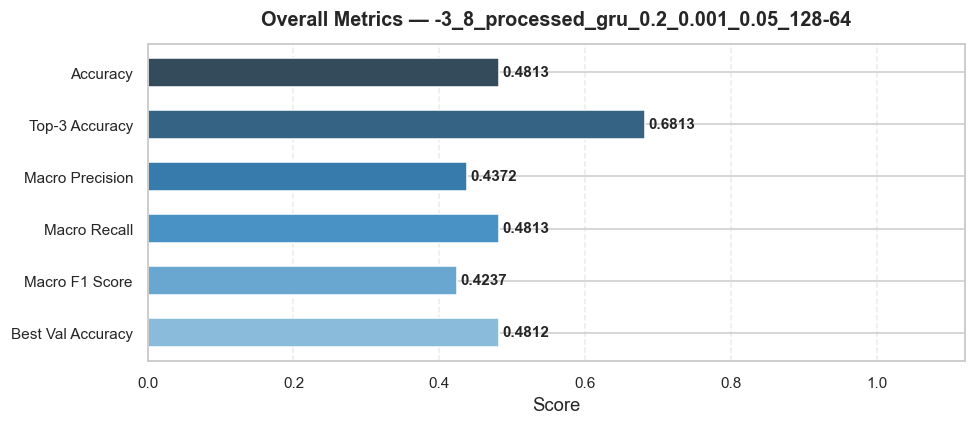

In [37]:
overall_rows = [
    ('Accuracy',           bm_metrics['accuracy']),
    ('Top-3 Accuracy',     bm_metrics['top3_accuracy']),
    ('Macro Precision',    bm_metrics['macro_precision']),
    ('Macro Recall',       bm_metrics['macro_recall']),
    ('Macro F1 Score',     bm_metrics['macro_f1']),
    ('Best Val Accuracy',  bm_analysis['underfitting']['best_val_acc']),
]

overall_df = pd.DataFrame(overall_rows, columns=['Metric', 'Value'])

display(
    overall_df.style
    .format({'Value': '{:.4f}'})
    .bar(subset=['Value'], color='#4c72b0', vmin=0, vmax=1)
    .set_caption('Best Model — Overall Evaluation Metrics')
    .hide(axis='index')
)

fig, ax = plt.subplots(figsize=(9, 4))
bar_labels = [r[0] for r in overall_rows]
bar_values = [r[1] for r in overall_rows]
bars = ax.barh(bar_labels[::-1], bar_values[::-1],
               color=sns.color_palette('Blues_d', len(bar_labels)),
               edgecolor='white', height=0.55)
for bar, val in zip(bars, bar_values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='semibold')
ax.set_xlim(0, 1.12)
ax.set_xlabel('Score', fontsize=12)
ax.set_title(f'Overall Metrics — {BEST_MODEL_NAME}', fontsize=13, fontweight='bold', pad=12)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### 9.3  Per-Class Metrics

In [38]:
per_class_rows = [
    {
        'Class':     cls,
        'Precision': v['precision'],
        'Recall':    v['recall'],
        'F1 Score':  v['f1'],
        'Support':   v['support'],
    }
    for cls, v in bm_metrics['per_class'].items()
]

pc_df = (
    pd.DataFrame(per_class_rows)
    .sort_values('F1 Score', ascending=False)
    .reset_index(drop=True)
)
pc_df.index += 1

metric_cols = ['Precision', 'Recall', 'F1 Score']
display(
    pc_df.style
    .format({c: '{:.4f}' for c in metric_cols})
    .bar(subset=metric_cols, color='#90caf9', vmin=0, vmax=1)
    .highlight_max(subset=metric_cols, color='#c6efce')
    .highlight_min(subset=metric_cols, color='#ffc7ce')
    .set_caption('Best Model — Per-Class Metrics (ranked by F1 Score ↓)')
)

,Class,Precision,Recall,F1 Score,Support
1,เงิน,1.0000,0.8750,0.9333,16
2,ใช่,0.9286,0.8125,0.8667,16
3,ขอโทษ,0.5357,0.9375,0.6818,16
4,โทรศัพท์,0.5357,0.9375,0.6818,16
5,สวัสดี,0.4286,0.3750,0.4000,16
6,ไม่ดี,0.2432,0.5625,0.3396,16
7,ดี,0.2000,0.2500,0.2222,16
8,อะไร,0.5000,0.0625,0.1111,16
9,ใคร,0.0000,0.0000,0.0000,16
10,ไม่,0.0000,0.0000,0.0000,16


### 9.4  Training Curves

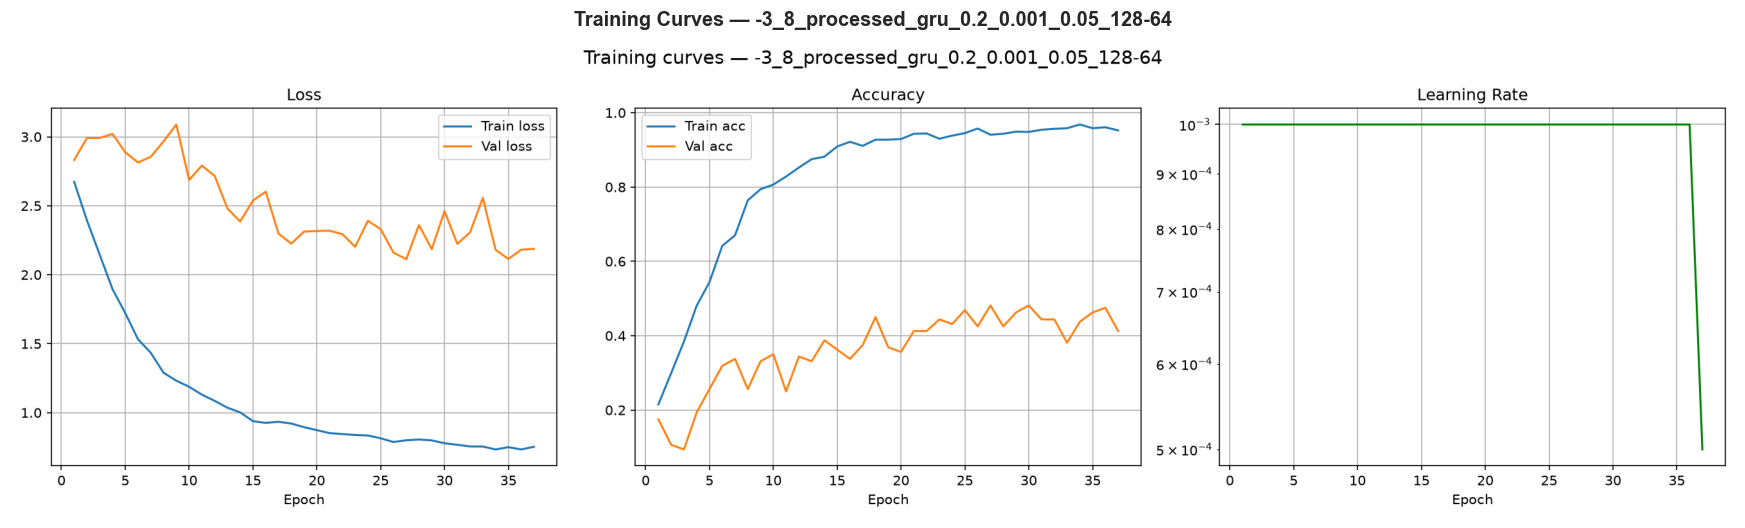

In [39]:
img_curves = plt.imread(BEST_MODEL_DIR / 'training_curves.png')
fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(img_curves)
ax.axis('off')
ax.set_title(f'Training Curves — {BEST_MODEL_NAME}', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### 9.5  Confusion Matrix

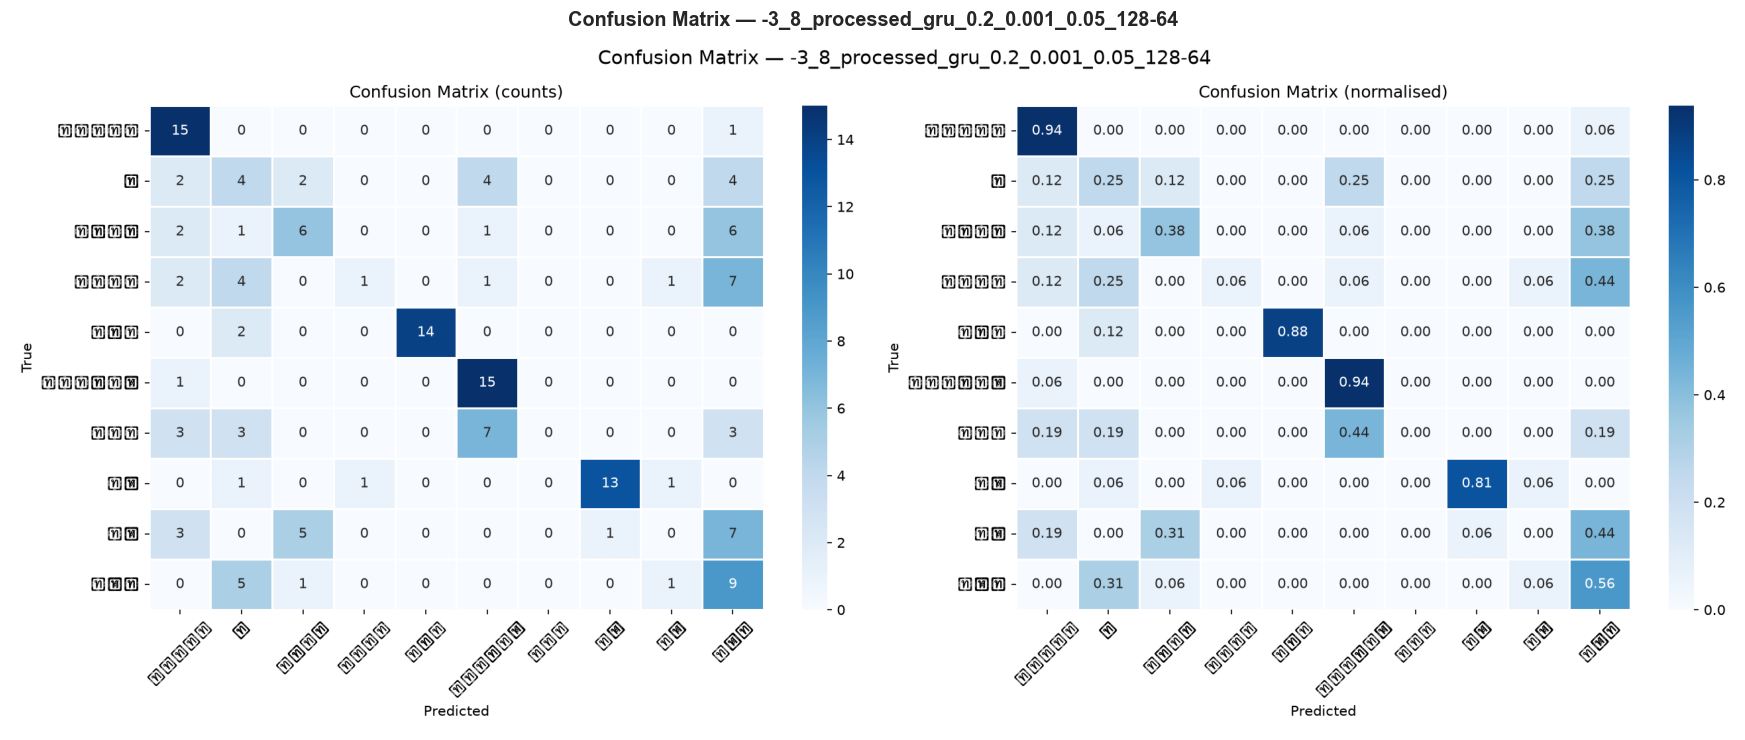

In [40]:
img_cm = plt.imread(BEST_MODEL_DIR / 'confusion_matrix.png')
fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(img_cm)
ax.axis('off')
ax.set_title(f'Confusion Matrix — {BEST_MODEL_NAME}', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### 9.6  Per-Class Metrics Chart

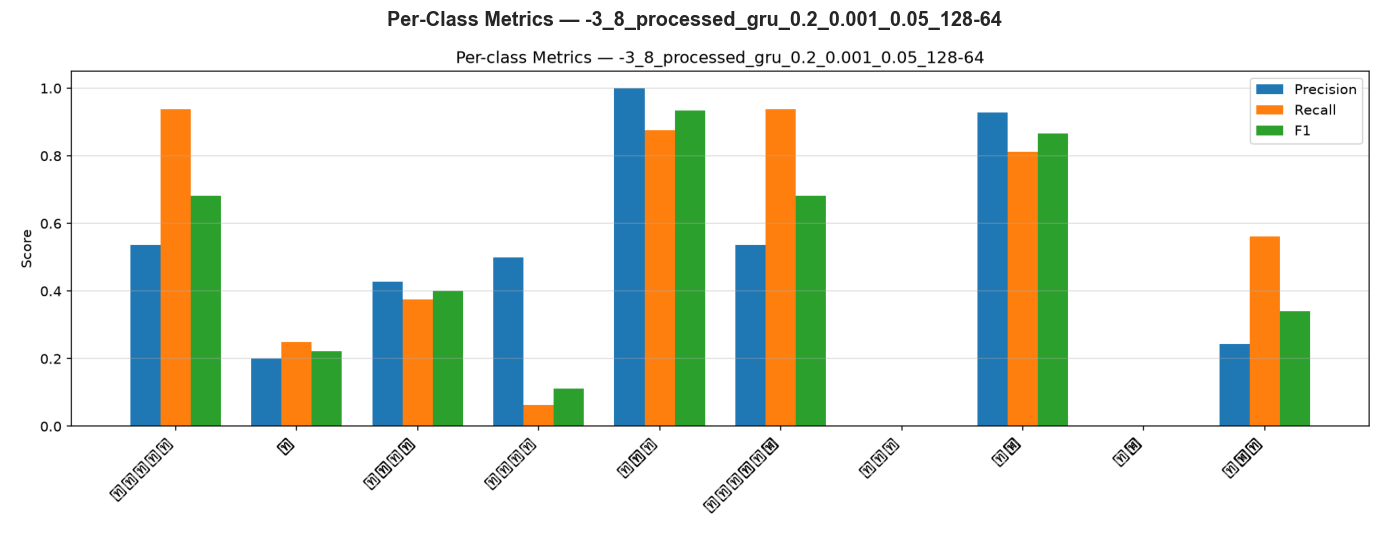

In [41]:
img_pc = plt.imread(BEST_MODEL_DIR / 'per_class_metrics.png')
fig, ax = plt.subplots(figsize=(14, 5))
ax.imshow(img_pc)
ax.axis('off')
ax.set_title(f'Per-Class Metrics — {BEST_MODEL_NAME}', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

### 9.7  Analysis Insights

In [42]:
sep = '=' * 60

print(sep)
print('  Generalisation Status')
print(sep)
ov = bm_analysis['overfitting']
un = bm_analysis['underfitting']
print(f'  Overfitting  detected : {ov["detected"]}  (train–val gap: {ov["train_val_gap"]:.4f})')
print(f'  Underfitting detected : {un["detected"]}  (best val acc:  {un["best_val_acc"]:.4f})')

print(f'\n{sep}')
print('  Class Performance Extremes')
print(sep)
print(f'  Strongest classes : {", ".join(bm_analysis["strongest_classes"])}')
print(f'  Weakest classes   : {", ".join(bm_analysis["weakest_classes"])}')

print(f'\n{sep}')
print('  Top Most Confused Pairs (True → Predicted)')
print(sep)
confused_df = pd.DataFrame(bm_analysis['most_confused_pairs'])
confused_df.index += 1
display(
    confused_df.style
    .bar(subset=['count'], color='#ff9999', vmin=0)
    .set_caption('Most frequent misclassification pairs')
)

  Generalisation Status
  Overfitting  detected : True  (train–val gap: 0.4712)
  Underfitting detected : True  (best val acc:  0.4812)

  Class Performance Extremes
  Strongest classes : เงิน, ใช่, โทรศัพท์
  Weakest classes   : ใคร, ไม่, อะไร

  Top Most Confused Pairs (True → Predicted)


,true,pred,count
1,ใคร,โทรศัพท์,7
2,ไม่,ไม่ดี,7
3,อะไร,ไม่ดี,7
4,สวัสดี,ไม่ดี,6
5,ไม่ดี,ดี,5
6,ไม่,สวัสดี,5
7,ดี,ไม่ดี,4
8,อะไร,ดี,4
9,ดี,โทรศัพท์,4
10,ใคร,ไม่ดี,3
